In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
data = np.loadtxt("data.txt")

x = data[:, 0];
y = data[:, 1];
z = data[:, 2];

print("Data set:")
print(data[:])

Data set:
[[0.   0.8  3.75]
 [0.   6.2  1.85]
 [0.   4.3  6.5 ]
 [0.   4.7  8.1 ]
 [1.2  3.5  8.2 ]]


In [13]:
#design matrix
A = np.column_stack((x, y, np.ones_like(x)))

#least-squares solution
coeff, residuals, rank, sing = np.linalg.lstsq(A, z, rcond=None)

a, b, c = coeff

print("Fitted plane:")
print(f"z = {a:.6f}x + ({b:.6f})y + {c:.6f}")

Fitted plane:
z = 2.616752x + (-0.019796)y + 5.129183


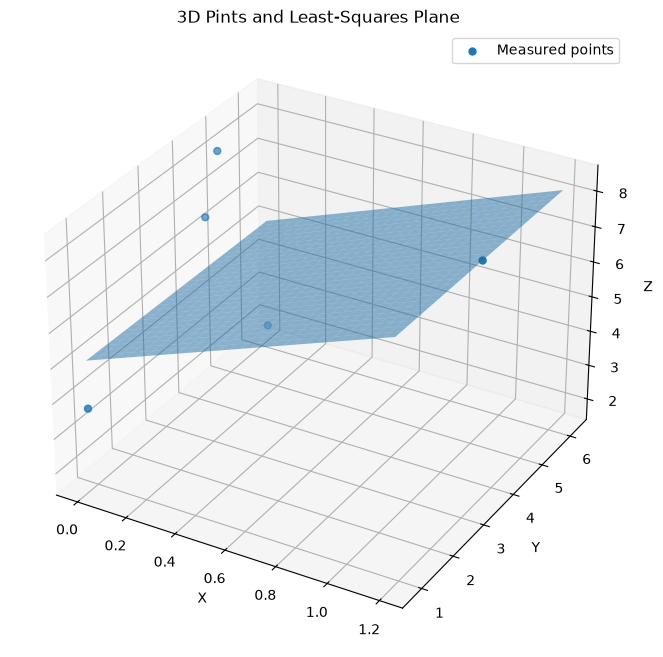

In [15]:
#grid
x_grid = np.linspace(x.min(), x.max(), 30)
y_grid = np.linspace(y.min(), y.max(), 30)

X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

#fitted plane
Z_grid = a * X_grid + b * Y_grid + c

#3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Original points
ax.scatter(x, y, z, s=25, label="Measured points")

#Fitted plane
ax.plot_surface(X_grid, Y_grid, Z_grid, alpha=0.5)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("3D Pints and Least-Squares Plane")

ax.legend()

plt.show()

In [16]:
# Predicted z values
z_pred = A @ coefficients

# Errors
errors = z - z_pred

# RMSE
rmse = np.sqrt(np.mean(errors**2))

# R²
ss_res = np.sum(errors**2)
ss_tot = np.sum((z - np.mean(z))**2)

r2 = 1 - ss_res / ss_tot

print(f"RMSE = {rmse:.6f}")
print(f"R² = {r2:.6f}")

RMSE = 2.160040
R² = 0.254025
